In [1]:
%load_ext autoreload
%autoreload 2
%env TORCH_COMPILE_DISABLE=1

env: TORCH_COMPILE_DISABLE=1


In [2]:
from brain_image.model.comm_alignment import CommAlignmentModel
from brain_image.model.prior import SimpleDiffusionPrior
from brain_image.utils import get_submodules_with_pattern
from brain_image.model.prior import DiffusionPriorConfig
from brain_image.data.data import get_from_batch

from pathlib import Path
import itertools as it
import numpy as np
from torch import Tensor
from torch.nn import functional as F
import tqdm
import pandas as pd
import torch

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [3]:
comm_cp = Path("checkpoints/train_comm-15445420-20260206_021738/version_0/checkpoints/epoch_0033-val_loss_17.7101.ckpt")
prior_cp = Path("checkpoints/train_eeg-15445445-20260206_025856/version_0/checkpoints/epoch_0484-val_loss_0.4309.ckpt")

comm = CommAlignmentModel.load_from_checkpoint(comm_cp)

state_dict = torch.load(prior_cp)
prior_config = state_dict["hyper_parameters"]["config"]["prior"]
prior_state_dict = get_submodules_with_pattern(state_dict["state_dict"], "prior")
prior = SimpleDiffusionPrior(
    DiffusionPriorConfig(**prior_config),
    embedding_stats=comm.data_module.get_embedding_stats()["align_img_latent"]
)
prior.load_state_dict(prior_state_dict)

Seed set to 42


<All keys matched successfully>

In [4]:
device = torch.device("cuda")
prior.eval()
prior.to(device)
comm.eval()
comm.to(device)

example_batch = next(iter(comm.data_module.get_dataloader("test")))
example_batch.keys()

dict_keys(['img_path', 'eeg_data', 'idx', 'sub', 'align_img_latent'])

In [ ]:

values = []

ns = list(np.linspace(0, 30, 20).astype(int))
gs = list(np.linspace(0, 4, 20))
params = list(it.product(ns, gs))

for n, g in tqdm.tqdm(params):
    with torch.no_grad():
        target = get_from_batch("align_img_latent", example_batch, Tensor).to(device)
        eeg = get_from_batch("eeg_data", example_batch, Tensor).to(device)
        eeg_latent = F.normalize(comm.eeg_encoder(eeg), dim=-1)
        clip_pred = prior.generate(conditioning=eeg_latent, guidance_scale=g, num_steps=n)
        mean_sim = round(F.cosine_similarity(target, clip_pred, dim=-1).mean().item(), 5)
        std_sim = round(F.cosine_similarity(target, clip_pred, dim=-1).std().item(), 5)
        
        values.append((n, g, mean_sim, std_sim))


df = pd.DataFrame(values, columns=["n", "g", "mean_sim", "std_sim"])
df = df.sort_values("mean_sim", ascending=False)
df

  0%|          | 0/400 [00:00<?, ?it/s]/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/diffusers/schedulers/scheduling_ddpm.py:307: RuntimeWarning: divide by zero encountered in scalar floor_divide
  step_ratio = self.config.num_train_timesteps // self.num_inference_steps
100%|██████████| 400/400 [00:33<00:00, 11.78it/s]


,n,g,mean_sim,std_sim
65,4,1.052632,0.76876,0.07987
106,7,1.263158,0.76847,0.07748
110,7,2.105263,0.76841,0.08012
67,4,1.473684,0.76770,0.08357
86,6,1.263158,0.76735,0.07939
...,...,...,...,...
8,0,1.684211,0.49638,0.05855
6,0,1.263158,0.49628,0.05831
13,0,2.736842,0.49540,0.05902
4,0,0.842105,0.49484,0.06149


In [ ]:
from typing import Literal


def get_faux_target(target, strength: float = 0.1, faux_type: Literal["noise", "drop"] = "noise"):
    n = target.size(0)
    device = target.device
    if faux_type == "noise":
        return torch.randn_like(target) * target.std(dim=0, keepdim=True) * strength + target
    elif faux_type == "drop":
        mask = torch.rand(n, device=device).unsqueeze(1) > strength
        return mask * target

In [60]:
%uv pip install flax

/home/gasparyanartur/dev/brain-image-implementation/.venv/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.schedulers.deprecated.scheduling_karras_ve import KarrasVeScheduler

karras_sched =  KarrasVeScheduler()
karras_sched.step()

KarrasVeScheduler {
  "_class_name": "KarrasVeScheduler",
  "_diffusers_version": "0.35.2",
  "s_churn": 80,
  "s_max": 50,
  "s_min": 0.05,
  "s_noise": 1.007,
  "sigma_max": 100,
  "sigma_min": 0.02
}

In [72]:

karras_sched_state = karras_sched.set_timesteps(karras_sched_state, num_inference_steps=50)
karras_sched_state

KarrasVeSchedulerState(num_inference_steps=50, timesteps=Array([49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33,
       32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16,
       15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0],      dtype=int32), schedule=Array([3.99999990e-04, 5.66289178e-04, 8.01708666e-04, 1.13499747e-03,
       1.60684367e-03, 2.27484549e-03, 3.22055118e-03, 4.55940841e-03,
       6.45485939e-03, 9.13829263e-03, 1.29373055e-02, 1.83156412e-02,
       2.59298738e-02, 3.67095210e-02, 5.19705154e-02, 7.35758543e-02,
       1.04163140e-01, 1.47466138e-01, 2.08771214e-01, 2.95562208e-01,
       4.18434232e-01, 5.92387021e-01, 8.38656783e-01, 1.18730569e+00,
       1.68089592e+00, 2.37968326e+00, 3.36897230e+00, 4.76953411e+00,
       6.75233889e+00, 9.55944157e+00, 1.35335293e+01, 1.91597290e+01,
       2.71248703e+01, 3.84013214e+01, 5.43656349e+01, 7.69666824e+01,
       1.08963562e+02, 1.54262222e+02, 2.18392624e+02,

In [ ]:
karras_sched.

In [74]:
prior.scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.35.2",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

In [35]:
#torch.manual_seed(42)
from brain_image.metrics import get_retrieval_accuracy

with torch.no_grad():
    target = get_from_batch("align_img_latent", example_batch, Tensor).to(device)
    faux_target = get_faux_target(target, strength=2)
    eeg = get_from_batch("eeg_data", example_batch, Tensor).to(device)
    eeg_latent = comm.eeg_encoder(eeg)
    eeg_latent_normed = F.normalize(eeg_latent, dim=-1)
    clip_pred = prior.generate(conditioning=eeg_latent_normed, guidance_scale=1.0, num_steps=15, unscale=True)

    print(clip_pred.mean(dim=0).mean(), clip_pred.std(dim=0).mean(), target.mean(dim=0).mean(), target.std(dim=0).mean())
    print(clip_pred.norm(dim=-1).mean(), target.norm(dim=-1).mean())
    print(F.cosine_similarity(target, clip_pred, dim=-1).mean())

    z_proto_gt = comm.comm.encode_feature([eeg_latent, target], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)
    z_proto_pred = comm.comm.encode_feature([eeg_latent, clip_pred], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)
    z_img_target = comm.comm.encode_feature([target], comm.config.img_idx, skip_encoder=True)

    z_proto_faux = comm.comm.encode_feature([eeg_latent, faux_target], [comm.config.eeg_idx, comm.config.img_idx], skip_encoder=True)

    acc_proto_to_img, acc_img_to_proto = get_retrieval_accuracy(z_proto_pred, z_img_target, norm=True)
    acc_proto_to_img_target, acc_img_to_proto_target = get_retrieval_accuracy(z_proto_gt, z_img_target, norm=True)
    acc_proto_to_img_faux, acc_img_to_proto_faux = get_retrieval_accuracy(z_proto_faux, z_img_target, norm=True)
    print(f"acc_proto_to_img: {acc_proto_to_img}")
    print(f"acc_img_to_proto: {acc_img_to_proto}")

    print(f"acc_proto_to_img_target: {acc_proto_to_img_target}")
    print(f"acc_img_to_proto_target: {acc_img_to_proto_target}")

    print(f"acc_proto_to_img_faux: {acc_proto_to_img_faux}")
    print(f"acc_img_to_proto_faux: {acc_img_to_proto_faux}")

    print(get_retrieval_accuracy(clip_pred, target, norm=True))

    print(F.cosine_similarity(z_proto_pred, z_img_target, dim=-1).mean().item())
    print(F.cosine_similarity(z_proto_gt, z_img_target, dim=-1).mean().item())

    print(F.cosine_similarity(z_proto_faux, z_img_target, dim=-1).mean().item())

tensor(-0.0575, device='cuda:0') tensor(0.1288, device='cuda:0') tensor(-0.0571, device='cuda:0') tensor(0.3318, device='cuda:0')
tensor(10.2506, device='cuda:0') tensor(13.3354, device='cuda:0')
tensor(0.7589, device='cuda:0')
acc_proto_to_img: 0.3199999928474426
acc_img_to_proto: 0.38999998569488525
acc_proto_to_img_target: 0.8849999904632568
acc_img_to_proto_target: 0.98499995470047
acc_proto_to_img_faux: 0.4699999988079071
acc_img_to_proto_faux: 0.6499999761581421
(tensor(0.2100, device='cuda:0'), tensor(0.0650, device='cuda:0'))
0.44032710790634155
0.6225699186325073
0.45307493209838867


In [49]:
C = 32
z1_proto_pred, z2_proto_pred, *_ = torch.chunk(z_proto_pred, C)
z1_img_target, z2_img_target, *_ = torch.chunk(z_img_target, C)
z1_proto_faux, z2_proto_faux, *_ = torch.chunk(z_proto_faux, C)

print(F.cosine_similarity(z1_proto_faux, z1_img_target).detach().cpu(), "Faux proto (2std), Real target")
print(F.cosine_similarity(z1_proto_pred, z1_img_target).detach().cpu(), "Pred proto, Real target")
print(F.cosine_similarity(z1_img_target, z2_img_target).detach().cpu(), "Wrong target, Real target")

tensor([0.6091, 0.4585, 0.5436, 0.4247, 0.3843, 0.5332, 0.5748]) Faux proto (2std), Real target
tensor([0.5534, 0.5158, 0.4558, 0.5218, 0.2015, 0.4610, 0.5388]) Pred proto, Real target
tensor([0.2156, 0.2542, 0.6027, 0.3736, 0.0857, 0.2991, 0.5179]) Wrong target, Real target


In [57]:
print(clip_pred[:5:, :5].detach().cpu(), "Predicted img embedding [:5, :5]")
print(target[:5, :5].detach().cpu(), "Target img embedding [:5, :5]")

tensor([[-0.1688,  0.3406,  0.0516, -0.4444, -0.0978],
        [ 0.2179, -0.0010, -0.0400, -0.6553,  0.1288],
        [ 0.0265,  0.4458, -0.5691, -0.6101,  0.0432],
        [ 0.2460,  0.2535, -0.0915, -0.6128, -0.0157],
        [ 0.1142,  0.1613, -0.0607, -0.8683,  0.2020]]) Predicted img embedding [:5, :5]
tensor([[ 0.0828,  0.5718,  0.2036, -0.3485, -0.0911],
        [ 0.4780, -0.3975,  0.1124, -0.7704, -0.1343],
        [ 0.1215,  1.3899, -1.0008, -0.8444, -0.0954],
        [ 0.1026,  0.1777, -0.0129, -0.3795, -0.0580],
        [ 0.0089,  0.1848, -0.4509, -0.8934, -0.0066]]) Target img embedding [:5, :5]


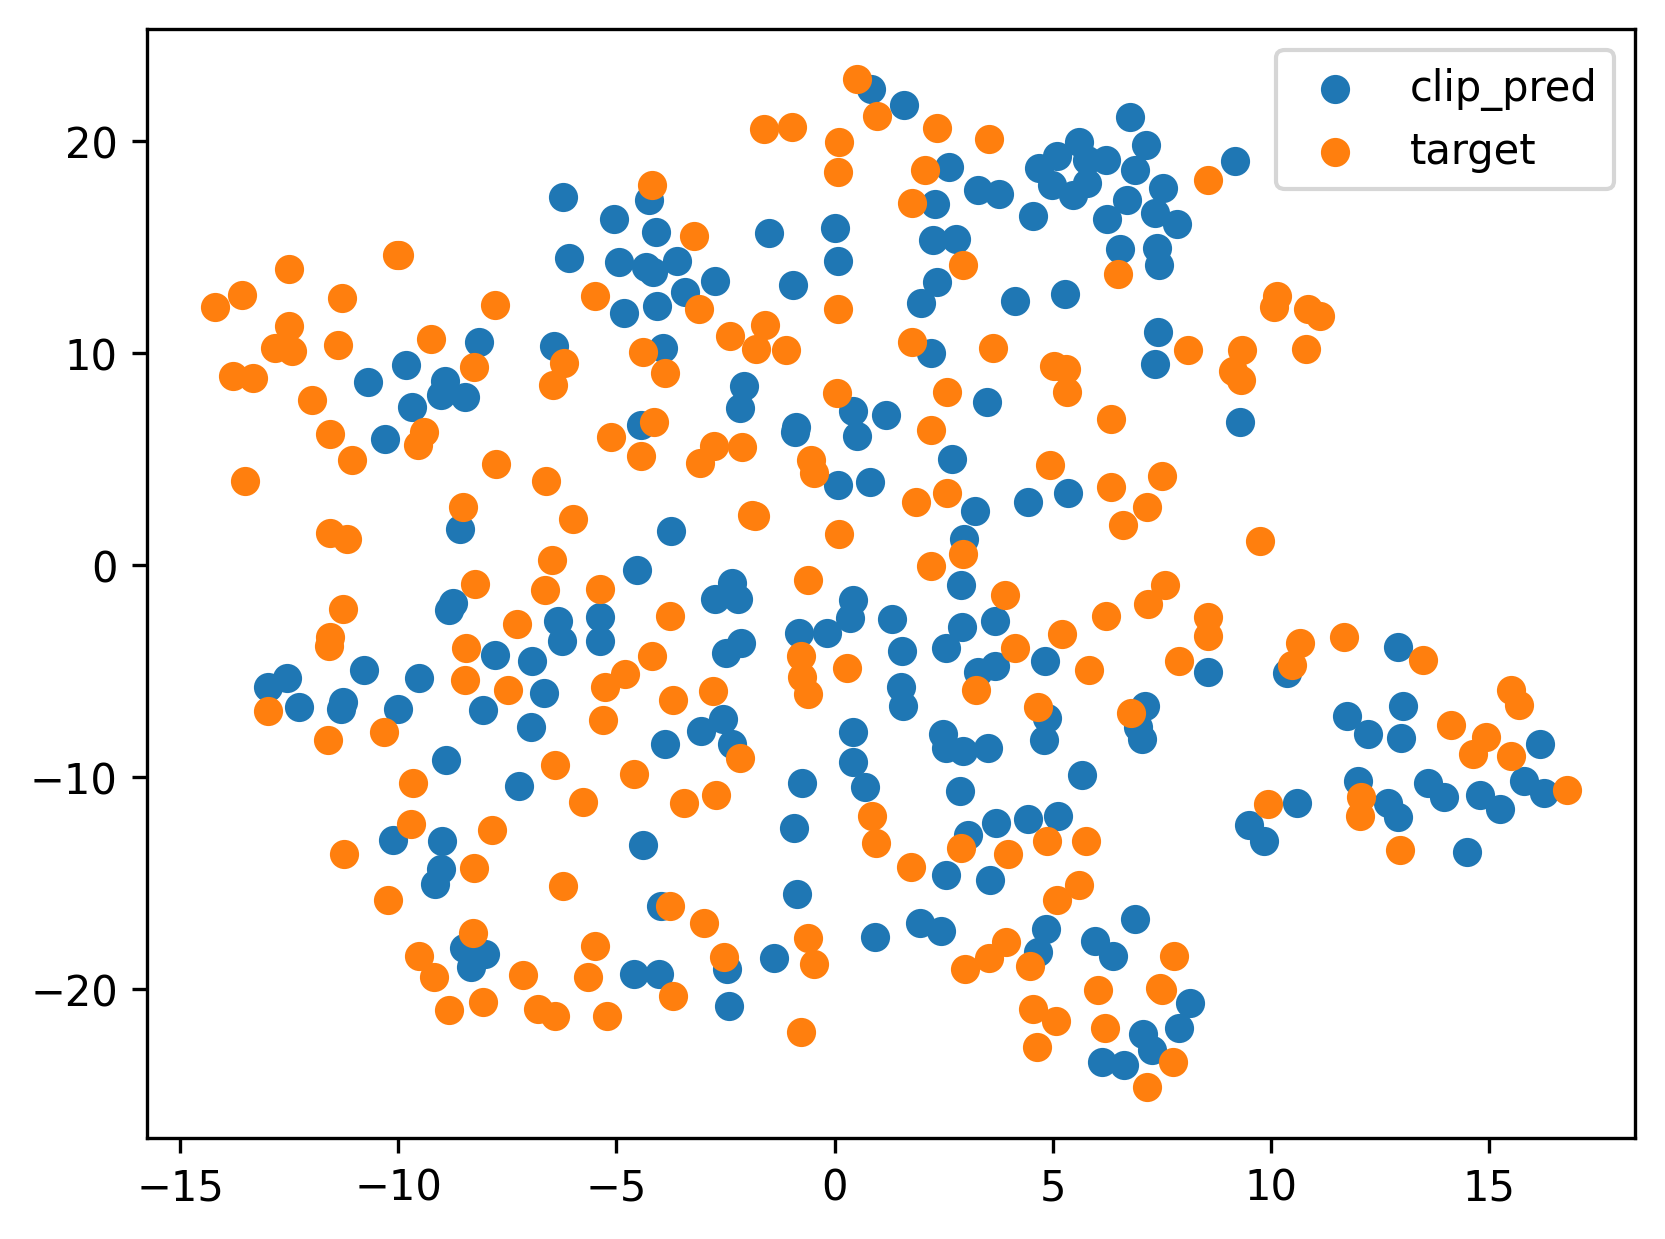

In [13]:
from brain_image.stats import plot_projected_latents

plot_projected_latents([clip_pred, target], ["clip_pred", "target"])

In [86]:
# Important dimensions

from torch import pca_lowrank

U, S, Vh = pca_lowrank(target, q=100, center=True, niter=5)
print(S, len(S))

print(Vh.shape)

explained_variance = Vh.cumsum(1) / Vh.sum()
print(explained_variance[0])

tensor([48.7136, 46.3122, 35.8157, 30.8014, 28.7028, 25.7184, 23.3673, 21.4505,
        20.7176, 20.0486, 18.5208, 17.1476, 16.7373, 16.1592, 15.4213, 14.8743,
        14.6403, 14.1214, 13.7509, 13.3851, 12.5628, 12.2879, 11.9417, 11.7420,
        11.5226, 11.2390, 11.0233, 10.9505, 10.7194, 10.6947, 10.2498, 10.0156,
         9.8653,  9.7265,  9.4935,  9.4093,  9.2182,  8.8318,  8.7095,  8.6839,
         8.5294,  8.5112,  8.4301,  8.3918,  8.2424,  8.1211,  7.9835,  7.8342,
         7.7731,  7.6588,  7.4500,  7.3892,  7.3168,  7.2866,  7.1871,  7.1273,
         6.9974,  6.9024,  6.8019,  6.7073,  6.6386,  6.5064,  6.4308,  6.3717,
         6.3094,  6.2767,  6.2431,  6.1284,  6.0859,  6.0484,  5.9747,  5.9453,
         5.9138,  5.8382,  5.7754,  5.7394,  5.6667,  5.5886,  5.5440,  5.4632,
         5.4259,  5.4116,  5.3577,  5.2631,  5.1973,  5.1607,  5.1109,  5.0578,
         5.0210,  4.9768,  4.8975,  4.8608,  4.7925,  4.7540,  4.6011,  4.5871,
         4.5444,  4.4819,  4.4525,  4.27